In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.base import clone
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error as RMSE, r2_score as R2, mean_absolute_error as MAE
import shap
import os

os.makedirs('../images', exist_ok=True)

In [46]:
# Load data
df = pd.read_csv('../data/processed/car_features.csv')

TARGET = 'Selling_Price'
FEATURES = [ col for col in df.columns if col != TARGET]

X = df[FEATURES]
y = df[TARGET]

print(TARGET)
print(FEATURES)

Selling_Price
['Present_Price', 'Driven_kms', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']


In [47]:
def get_oof_preds(X, y, model):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        fold_model = clone(model)
        fold_model.fit(X_train, y_train)
        oof_preds[test_idx] = fold_model.predict(X_test)

    return oof_preds


In [48]:
# Tuned paramters plus other basic ones
params = {
    'depth': 3,
    'iterations': 527,
    'learning_rate': 0.13434673091769583, 
    'l2_leaf_reg': 6.738561828677548, 
    'min_data_in_leaf': 11,
    'verbose': False,
    'random_state': 42
}

oof_preds = get_oof_preds(X, y, CatBoostRegressor(**params))

df['Predicted'] = oof_preds
df['Residual'] = df['Selling_Price'] - df['Predicted']
df['AbsError'] = df['Residual'].abs()

rmse = RMSE(df['Selling_Price'], df['Predicted'])
r2 = R2(df['Selling_Price'], df['Predicted'])

print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')
print(f'MAE: {df['AbsError'].mean():.4f}')

RMSE: 1.3556
R2: 0.9258
MAE: 0.6364


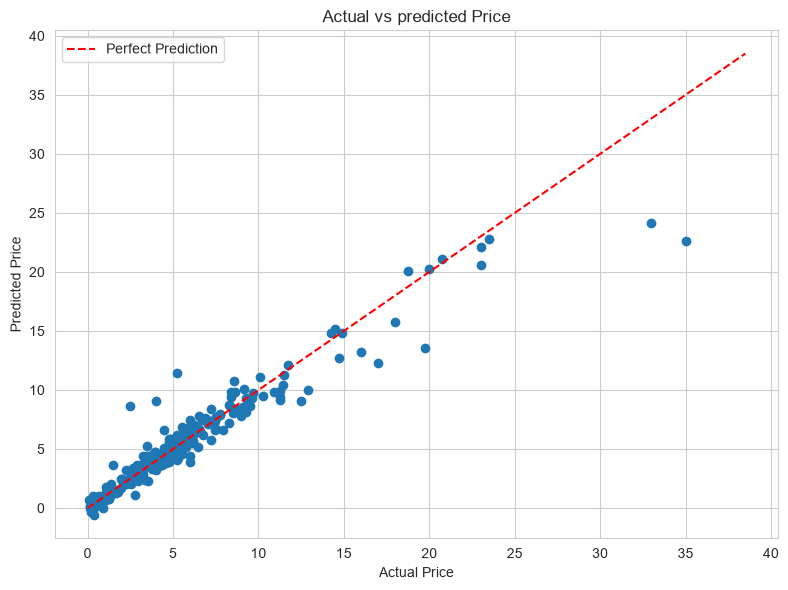

In [49]:
max_val = df['Selling_Price'].max() * 1.1

plt.figure(figsize=(8, 6))
plt.scatter(df['Selling_Price'], df['Predicted'])
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs predicted Price")
plt.legend()
plt.tight_layout()
plt.savefig("../images/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

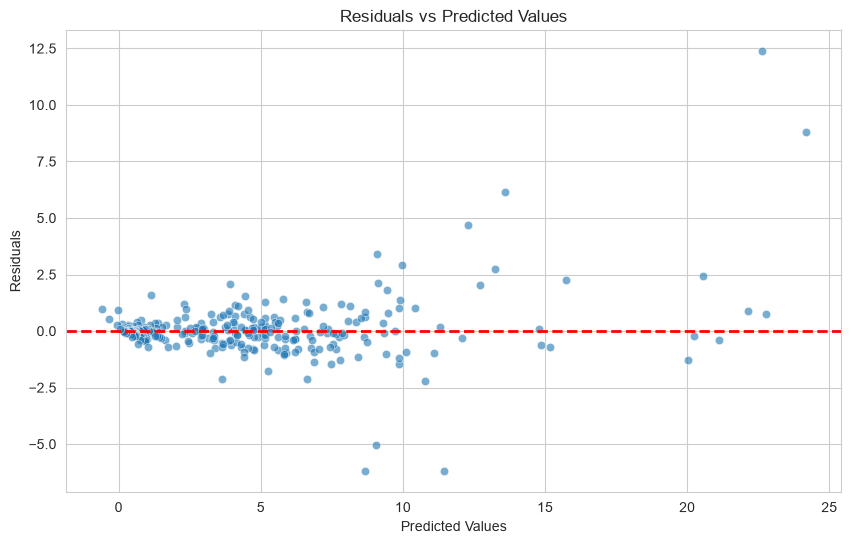

In [50]:
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='Predicted', y='Residual', alpha=0.6)
plt.axhline(y=0, color='red', linewidth=2, linestyle='--')

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()

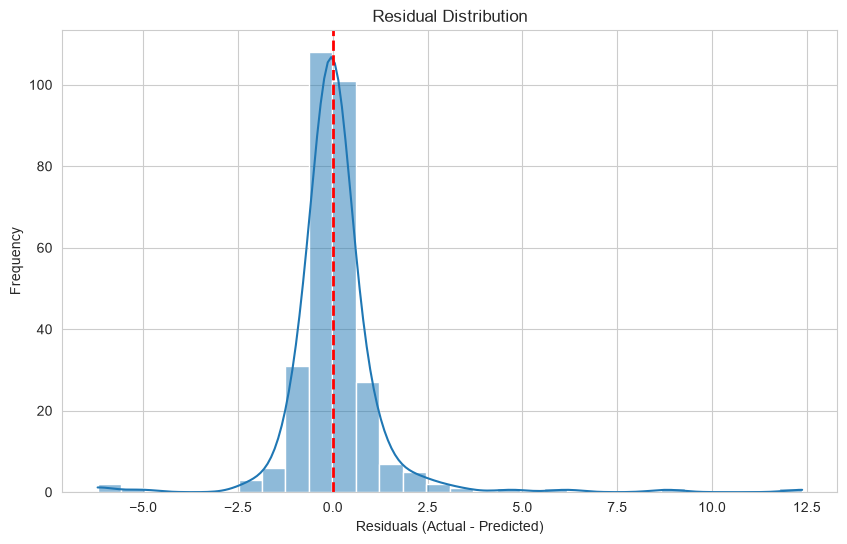

In [51]:

plt.figure(figsize=(10, 6))

sns.histplot(
    df['Residual'],
    bins=30,
    kde=True
)

plt.axvline(0, color='red', linewidth=2, linestyle='--')

plt.title("Residual Distribution")
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()

       Band       MAE      RMSE  Count
3       Low  0.172000  0.256384     76
0   Mid-Low  0.462809  0.913641     73
1  Mid-High  0.671058  1.145210     77
2      High  1.265579  2.299456     72


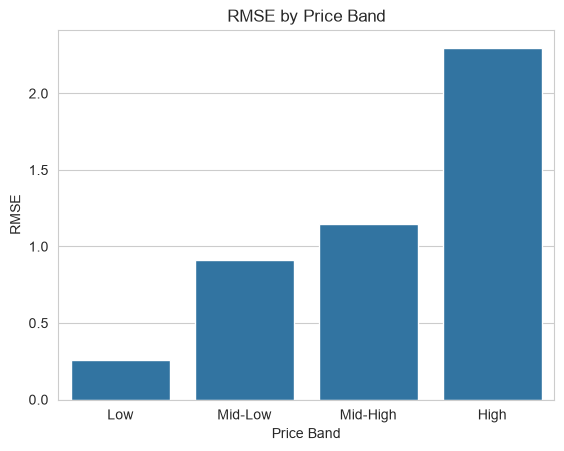

In [52]:
df['Price_Band'] = pd.qcut(
    df['Selling_Price'],
    q=4, 
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

results = []

for band in df['Price_Band'].dropna().unique():
    subset = df[df['Price_Band'] == band]

    y_true = subset['Selling_Price']
    y_pred = subset['Predicted']

    mae = MAE(y_true, y_pred)
    rmse = RMSE(y_true, y_pred)

    results.append({
        'Band': band,
        'MAE': mae,
        'RMSE': rmse,
        'Count': len(subset)
    })

df['Price_Band'] = pd.Categorical(
    df['Price_Band'],
    categories=['Low', 'Mid-Low', 'Mid-High', 'High'],
    ordered=True
)

band_metrics = pd.DataFrame(results).sort_values('Band')
band_metrics['Band'] = pd.Categorical(band_metrics['Band'], categories=['Low', 'Mid-Low', 'Mid-High', 'High'], ordered=True)
band_metrics = band_metrics.sort_values('Band')

print(band_metrics)

sns.barplot(
    data=band_metrics,
    x="Band",
    y="RMSE"
)

plt.title("RMSE by Price Band")
plt.xlabel("Price Band")
plt.ylabel("RMSE")
plt.show()

In [53]:
df.sort_values('AbsError', ascending=False).head(15)

,Selling_Price,Present_Price,Driven_kms,Selling_type,Transmission,Owner,Car_Age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Predicted,Residual,AbsError,Price_Band
85,35.00,92.60,78000,0,0,0,8,0,1,0,22.623485,12.376515,12.376515,High
63,33.00,36.23,6000,0,1,0,1,0,1,0,24.183818,8.816182,8.816182,High
77,5.25,22.83,80000,0,1,0,8,0,0,1,11.451828,-6.201828,6.201828,Mid-High
84,2.50,23.73,142000,1,1,3,12,0,0,1,8.680235,-6.180235,6.180235,Mid-Low
65,19.75,23.15,11000,0,1,0,1,0,0,1,13.597182,6.152818,6.152818,High
92,4.00,22.78,89000,0,1,0,10,0,0,1,9.049112,-5.049112,5.049112,Mid-High
95,17.00,18.64,8700,0,0,0,1,0,0,1,12.292243,4.707757,4.707757,High
82,12.50,13.46,38000,0,0,0,3,0,1,0,9.101797,3.398203,3.398203,High
247,12.90,13.60,35934,0,0,0,2,0,1,0,9.982892,2.917108,2.917108,High
52,16.00,30.61,135000,1,1,0,5,0,1,0,13.253590,2.746410,2.746410,High


In [54]:
df.sort_values('AbsError', ascending=False).tail(15)

,Selling_Price,Present_Price,Driven_kms,Selling_type,Transmission,Owner,Car_Age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Predicted,Residual,AbsError,Price_Band
169,0.40,0.55,6700,1,0,0,3,0,0,1,0.381424,0.018576,0.018576,Low
116,1.10,1.47,26000,1,0,0,3,0,0,1,1.082817,0.017183,0.017183,Mid-Low
112,1.15,1.47,17000,1,0,0,3,0,0,1,1.166598,-0.016598,0.016598,Mid-Low
240,6.25,7.60,7000,0,0,0,2,0,0,1,6.233750,0.016250,0.016250,High
194,0.16,0.51,33000,1,0,0,8,0,0,1,0.175325,-0.015325,0.015325,Low
131,0.72,0.95,500,1,0,0,2,0,0,1,0.734762,-0.014762,0.014762,Low
182,0.25,0.75,26000,1,0,1,10,0,0,1,0.263870,-0.013870,0.013870,Low
154,0.48,0.52,15000,1,0,0,1,0,0,1,0.466785,0.013215,0.013215,Low
153,0.48,0.51,4300,1,1,0,1,0,0,1,0.467387,0.012613,0.012613,Low
167,0.40,0.54,14000,1,0,0,3,0,0,1,0.412085,-0.012085,0.012085,Low


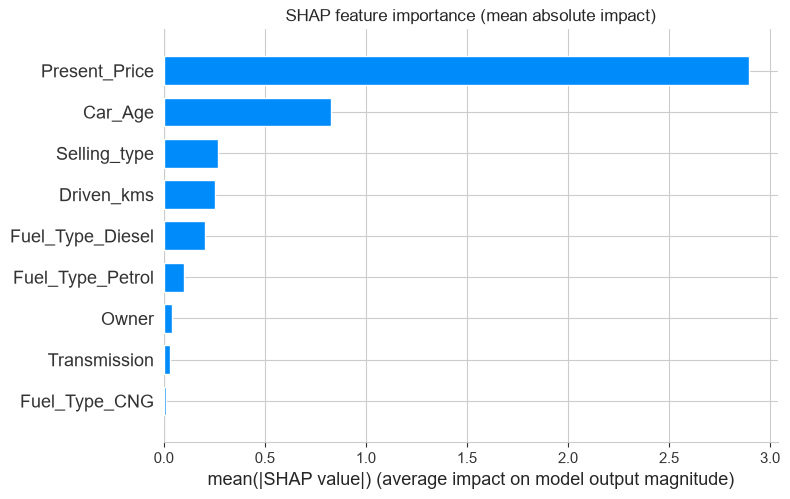

In [55]:
final_model = CatBoostRegressor(**params)
final_model.fit(X, y)

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X,
    plot_type='bar',
    show=False
)

plt.title("SHAP feature importance (mean absolute impact)")
plt.tight_layout()
plt.savefig("../images/06_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

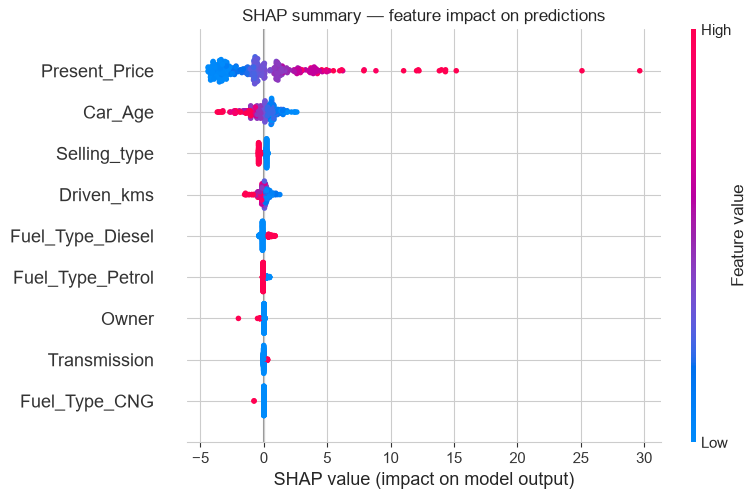

In [56]:
shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.title("SHAP summary — feature impact on predictions")
plt.tight_layout()
plt.savefig("../images/06_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [60]:
df['Above_10_lakhs'] = np.where(df['Selling_Price'] > 10, 0, 1)
print(df['Above_10_lakhs'].value_counts())

Above_10_lakhs
1    271
0     27
Name: count, dtype: int64


## Evaluation Summary

### Out-of-fold performance
RMSE: 1.3556 Lakhs | R²: 0.9258 | MAE: 0.6364 Lakhs

This is the more rigorous number compared to the 1.1961 RMSE reported in
05_modelling.ipynb — that figure was an average of 5 per-fold RMSEs, while this one
is computed on all 298 out-of-fold predictions pooled together. The two differ
because averaging RMSEs across folds is mathematically guaranteed to be ≤ the RMSE
of the pooled predictions (Jensen's inequality). This OOF figure is the one to trust
as the model's true generalisation performance.

### Residual diagnostics
- Residuals vs predicted shows a clear funnel shape — error variance grows as
  predicted price increases. The model is not equally reliable across the price range.
- Residual distribution is centered near zero and roughly symmetric, with a right
  tail of larger positive residuals — a handful of cars are noticeably underpredicted
  (actual price higher than predicted), concentrated among expensive vehicles.

### Error by price band
| Band | MAE | RMSE | Count |
|------|-----|------|-------|
| Low | 0.172 | 0.256 | 76 |
| Mid-Low | 0.463 | 0.914 | 73 |
| Mid-High | 0.671 | 1.145 | 77 |
| High | 1.266 | 2.299 | 72 |

RMSE increases monotonically from Low to High — a ~9x jump from the cheapest to
the most expensive quartile. The model is excellent on mainstream/budget cars and
meaningfully less precise on premium vehicles.

### Worst and best predictions
The 15 largest errors are almost entirely high-Present_Price vehicles (Present_Price
18-93 Lakhs) — cars where a large gap between Present_Price and Selling_Price (heavy
depreciation, unusual for the model, or luxury-segment pricing quirks) confuses the
model. The 15 smallest errors are dominated by low-Present_Price economy cars
(Present_Price under ~1.5 Lakhs), several predicted within a few thousand rupees of
the actual price.

### SHAP feature impact
Confirms and extends the CatBoost feature importance from modelling: Present_Price
has by far the largest and most consistent impact — higher Present_Price pushes
predictions up sharply and near-linearly. Car_Age is the clear second driver, with
higher age pushing predictions down. Remaining features (Selling_type, Driven_kms,
Fuel_Type, Transmission, Owner) contribute small, secondary adjustments.

### Business interpretation
This model is reliable for its actual use case — pricing typical used cars, which
make up the bulk of any real marketplace (economy and mid-range vehicles). For a
budget or mid-range car, predictions are trustworthy to within a few thousand to a
few tens of thousands of rupees. For premium/luxury vehicles, error grows
substantially (RMSE ~2.3 Lakhs in the top price quartile) — a direct consequence of
having very few high-value examples in a 298-row dataset to learn from, combined
with genuinely higher price variance at that end of the market (luxury pricing
depends more on condition, brand prestige, and negotiation than the features
available here).

**Practical recommendation:** trust the model's output directly for cars priced
under ~10 Lakhs. For predictions above that threshold, flag them for human review
rather than treating the number as final — the model's own error pattern tells you
exactly where to apply that caution.

### Limitations
- Small dataset (298 rows) limits reliability, especially for rare segments (CNG,
  high-value cars)
- No true held-out test set — OOF predictions are honest but were still used
  indirectly to select the tuned hyperparameters in 05_modelling.ipynb
- Present_Price dominates the model almost entirely (78% importance); the model is
  in large part learning "used price ≈ some function of new price," which is
  intuitive but means it may not generalise well to markets or years where that
  relationship shifts (e.g. a used car market with different depreciation norms)